# Steps 2-6 - Split, prepare, engineer, train, evaluate

**Assignment 1: Housing Price Prediction** - Ames Housing, `SalePrice` regression.

This notebook continues from `01_eda.ipynb`. Every decision below cites the evidence
found there.

**The golden rule for this notebook:**

> **TRAIN teaches. TEST checks.**
>
> Preprocessing is *learned* from the training set and only *applied* to the test set.
> The test set is opened once, at the very end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

df = pd.read_csv("../data/raw/AmesHousing.csv")
print(f"rows: {df.shape[0]:,}   columns: {df.shape[1]}")

rows: 2,930   columns: 82


# Step 2 - Create training and test data

Why the test set is kept separate is answered in **REPORT.md, Q3**. In short: the test set
is used only by `model.predict(X_test)` and the metric calls in Step 6.

## 2.2 Choosing the split, and testing our own reasoning

We use a **stratified** 80/20 split on `Overall Qual`, banded to merge the sparse tails.

### The reasoning we started with

`Overall Qual` is the strongest single predictor (r = 0.80, Step 1.5). Our test set is only
586 rows, and just 138 houses in the whole dataset are quality 9-10. A plain random split
could hand us noticeably more or fewer of those than the dataset average, so we expected
stratification to make the test score **less dependent on the random seed**.

### We tested that assumption, and it was wrong

That expectation is checkable, so we checked it: 200 random seeds per arm, identical
preprocessing and model, with only the split method differing (Appendix A).

| Split | mean RMSE | sd of RMSE | worst band drift |
|---|---|---|---|
| random | \$30,063 | \$6,711 | 5.29 pp |
| stratified | \$30,361 | \$6,730 | **0.07 pp** |

Stratification does exactly what it claims at the level it operates on: the largest deviation
of any quality band from its dataset-wide proportion falls from 5.29 percentage points to
0.07. But that **does not propagate to the score**. The variance ratio is 1.005 (F-test
p = 0.97) and the difference in means is \$299 (Welch t-test p = 0.66). On both measures the
two methods are indistinguishable.

The reason is that the spread of test RMSE is not driven by band proportions. It is driven by
*which individual expensive or anomalous houses* land in the test set. One house predicted
\$152,509 too low moves RMSE materially across 586 rows, and balancing quality bands does
nothing to control that.

### What we concluded

We keep the stratified split, but on honest grounds. It guarantees the test set is
representative on the strongest predictor, which is a reasonable aim in itself, and it
demonstrably costs nothing. What we no longer claim is that it stabilises the estimate,
because we measured that and it does not.

A plain random split would have been equally valid. This is a case where two defensible
choices turn out to be empirically equivalent, and the useful outcome is knowing that rather
than guessing.

### The finding that matters more

The same experiment showed something we would otherwise have missed: **the spread of test
RMSE across seeds is roughly \$6,700**, and our own result at `random_state=42` sits at the
**17th percentile** - better than 83% of possible splits. Section 6.2 returns to what that
means for reading the results table.


In [2]:
# Levels 1-3 hold only 57 houses in total, and 9-10 only 138. Stratification needs
# enough members per group, so we merge the sparse tails into broader bands.
qual_band = pd.cut(
    df["Overall Qual"],
    bins=[0, 4, 5, 6, 7, 8, 10],
    labels=["1-4", "5", "6", "7", "8", "9-10"],
)

print("Houses per stratification band:")
print(qual_band.value_counts().sort_index().to_string())

Houses per stratification band:
Overall Qual
1-4     283
5       825
6       732
7       602
8       350
9-10    138


In [3]:
train_set, test_set = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=qual_band,
)

print(f"training rows: {len(train_set):,}")
print(f"test rows    : {len(test_set):,}")

training rows: 2,344
test rows    : 586


## 2.3 Verify the split preserved the proportions

In [4]:
def band(frame):
    return pd.cut(frame["Overall Qual"], bins=[0, 4, 5, 6, 7, 8, 10],
                  labels=["1-4", "5", "6", "7", "8", "9-10"])

comparison = pd.DataFrame({
    "Overall (%)": qual_band.value_counts(normalize=True).sort_index() * 100,
    "Train (%)":   band(train_set).value_counts(normalize=True).sort_index() * 100,
    "Test (%)":    band(test_set).value_counts(normalize=True).sort_index() * 100,
}).round(1)
comparison

,Overall (%),Train (%),Test (%)
Overall Qual,,,
1-4,9.7,9.6,9.7
5,28.2,28.2,28.2
6,25.0,25.0,24.9
7,20.5,20.6,20.5
8,11.9,11.9,11.9
9-10,4.7,4.7,4.8


**Finding (answers Q3).** The quality bands match to within a few tenths of a percent across
all three columns, so the test set is a fair miniature of the dataset rather than a lucky or
unlucky draw.

From this point until Step 6, `test_set` is set aside and not inspected.

# Step 3 - Prepare the data

## 3.1 The three ideas to keep separate

| | What happens | Which data |
|---|---|---|
| **DEFINE** | `Pipeline(...)`, `ColumnTransformer(...)`, `SimpleImputer(...)` describe the recipe. Nothing is learned yet. | none |
| **LEARN** | `.fit(X_train, y_train)` learns imputation medians, scaling parameters, one-hot categories **and** the model's parameters. | training only |
| **APPLY** | `.predict(X_test)` applies the already-learned preparation, then predicts. | test |

Putting preprocessing *inside* the pipeline is what makes this automatic. If we imputed with
`df["Lot Frontage"].fillna(df["Lot Frontage"].median())` before splitting, that median would
have been computed from test rows too - a small leak, invisible in the code, that inflates
the final score.

## 3.2 Four routes, not two

The usual teaching setup sends numbers one way and text the other. The EDA showed that is too
coarse for this dataset, because `NaN` means two different things and because many text
columns are **ordered**. So columns are routed four ways:

| Route | Columns | Imputation | Encoding | Why |
|---|---|---|---|---|
| `num` | measurements and counts | **median** | standardise | NaN here is a genuine unknown |
| `ord` | ordered ratings (`Ex > Gd > TA > Fa > Po`, etc.) | constant `"NA"` | **ordinal**, explicit order | order is information; `"NA"` sits at 0, below "poor", which is correct when the feature is absent |
| `nom_absent` | `Alley`, `Fence`, `Misc Feature`, `Garage Type`, `Mas Vnr Type` | constant `"None"` | one-hot | NaN means *the feature does not exist* - that is a real category, not a gap |
| `nom_unknown` | remaining unordered categories | **most frequent** | one-hot | NaN here is a recording failure |

The `ord` route is the one that repays the extra effort. `Kitchen Qual` one-hot encoded becomes
five unordered columns and the model must rediscover from data that `Ex > Gd`. Ordinal encoded
it is one column that already says so.

### The main limitation of ordinal encoding

Ordinal encoding fixes the *order* but imposes an assumption we should state plainly: by
encoding `Po=1, Fa=2, TA=3, Gd=4, Ex=5`, we tell a linear model that **every step up is worth
the same amount**. The training data says otherwise. Median sale price by `Kitchen Qual`:

| Step | Jump in median price |
|---|---|
| Po -> Fa | \$250 |
| Fa -> TA | \$28,750 |
| TA -> Gd | \$64,500 |
| Gd -> Ex | **\$124,624** |

The last step is roughly 500 times the first. So the encoding is directionally correct and
numerically wrong, and it still outperforms one-hot encoding because getting the *direction*
right matters more here than getting the spacing right. A tree-based model is unaffected,
since it only ever asks "is this value above or below a threshold".

A concrete improvement, listed again in 6.6: space the levels by their **training-set** median
price instead of by 1, 2, 3, 4, 5. That must be learned inside the pipeline, from training
folds only, or it becomes target leakage.


In [5]:

# Evidence that the rating levels are NOT evenly spaced in price.
qual_order = ["Po", "Fa", "TA", "Gd", "Ex"]
med   = df.groupby("Kitchen Qual")["SalePrice"].median().reindex(qual_order)
steps = med.diff()

print("Median SalePrice per Kitchen Qual level, and the jump at each step up:")
for lvl in qual_order:
    jump = steps[lvl]
    print(f"  {lvl:3s} ${med[lvl]:>9,.0f}" + (f"    step  +${jump:>9,.0f}" if pd.notna(jump) else ""))

s = steps.dropna()
print(f"\nThe largest step is {s.max() / s.min():,.0f}x the smallest, "
      f"so encoding these as 1, 2, 3, 4, 5 assumes a spacing the data does not support.")


Median SalePrice per Kitchen Qual level, and the jump at each step up:
  Po  $  107,500
  Fa  $  107,750    step  +$      250
  TA  $  136,500    step  +$   28,750
  Gd  $  201,000    step  +$   64,500
  Ex  $  325,624    step  +$  124,624

The largest step is 498x the smallest, so encoding these as 1, 2, 3, 4, 5 assumes a spacing the data does not support.


In [6]:
# ---------------------------------------------------------------------------
# ORDERED RATINGS
# Each list runs worst -> best. "NA" is placed first, so "no basement" or
# "no fireplace" encodes as 0, below even "poor". Taken from the dataset guide.
# ---------------------------------------------------------------------------
QUAL5      = ["NA", "Po", "Fa", "TA", "Gd", "Ex"]
ORDINAL_LEVELS = {
    "Exter Qual":     QUAL5,
    "Exter Cond":     QUAL5,
    "Bsmt Qual":      QUAL5,
    "Bsmt Cond":      QUAL5,
    "Heating QC":     QUAL5,
    "Kitchen Qual":   QUAL5,
    "Fireplace Qu":   QUAL5,
    "Garage Qual":    QUAL5,
    "Garage Cond":    QUAL5,
    "Pool QC":        QUAL5,
    "Bsmt Exposure":  ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFin Type 1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin Type 2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Garage Finish":  ["NA", "Unf", "RFn", "Fin"],
    "Lot Shape":      ["NA", "IR3", "IR2", "IR1", "Reg"],
    "Land Slope":     ["NA", "Sev", "Mod", "Gtl"],
    "Utilities":      ["NA", "NoSeWa", "NoSewr", "AllPub"],
    "Functional":     ["NA", "Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Paved Drive":    ["NA", "N", "P", "Y"],
    "Central Air":    ["NA", "N", "Y"],
}
ORDINAL_COLS = list(ORDINAL_LEVELS)

# Unordered categories where NaN means "this house does not have one".
NOM_ABSENT_COLS = ["Alley", "Fence", "Misc Feature", "Garage Type", "Mas Vnr Type"]

print(f"{len(ORDINAL_COLS)} ordered rating columns")
print(f"{len(NOM_ABSENT_COLS)} nominal columns where NaN = absence")

20 ordered rating columns
5 nominal columns where NaN = absence


### A note on `Central Air`, `Lot Shape` and friends

`Central Air` is binary (`Y`/`N`), so ordinal and one-hot encoding are equivalent for it; it is
listed as ordinal only to keep it in one column. `Lot Shape`, `Land Slope`, `Utilities`,
`Functional` and `Paved Drive` are marked "Category (ordered)" in the dataset guide, so their
order is taken from there rather than invented.

None of these five have missing values, so the leading `"NA"` level is never actually used -
it is included so that every ordinal column follows the same pattern.

# Step 4 - Select and engineer features

## 4.1 Features we create

All five new features are **row-wise arithmetic**: each one is computed from other values in
the *same row*. Nothing is learned from a column's distribution, so applying this function to
the test set cannot leak anything. That is precisely why it can live outside the pipeline,
while imputation and scaling must live inside it. This distinction is worth being able to
state out loud.

| New feature | Definition | Evidence from Step 1 |
|---|---|---|
| `Total SF` | `Total Bsmt SF + 1st Flr SF + 2nd Flr SF` | the separate area columns each correlate 0.6+ with price and overlap heavily; total floor area is what a buyer actually pays for |
| `Total Bath` | `Full Bath + 0.5*Half Bath + Bsmt Full Bath + 0.5*Bsmt Half Bath` | bathroom counts are split across four columns; a half bath is genuinely worth about half |
| `House Age` | `Yr Sold - Year Built` | `Year Built` correlates 0.56 with price, but a *year* is only meaningful relative to the sale |
| `Remod Age` | `Yr Sold - Year Remod/Add` | same logic for the most recent renovation |
| `Total Porch SF` | sum of the five porch/deck area columns | individually each is mostly zeros; combined they measure "outdoor space" |

A detail from the data: 3 houses record `Year Remod/Add` *after* `Yr Sold`, and 1 records
`Year Built` after it. Those are recording errors that would produce negative ages, so ages are
clipped at 0.

In [7]:
AGE_CLIP_NOTE = "3 rows have Year Remod/Add > Yr Sold; 1 has Year Built > Yr Sold"

def add_features(frame):
    """Row-wise derived features. No statistic is learned from any column,
    so this is safe to apply to train and test independently."""
    out = frame.copy()

    out["Total SF"] = (
        out["Total Bsmt SF"].fillna(0) + out["1st Flr SF"] + out["2nd Flr SF"]
    )
    out["Total Bath"] = (
        out["Full Bath"] + 0.5 * out["Half Bath"]
        + out["Bsmt Full Bath"].fillna(0) + 0.5 * out["Bsmt Half Bath"].fillna(0)
    )
    out["Total Porch SF"] = (
        out["Wood Deck SF"] + out["Open Porch SF"] + out["Enclosed Porch"]
        + out["3Ssn Porch"] + out["Screen Porch"]
    )
    # .clip(lower=0) handles the handful of rows where the recorded build or
    # remodel year is later than the sale year.
    out["House Age"] = (out["Yr Sold"] - out["Year Built"]).clip(lower=0)
    out["Remod Age"] = (out["Yr Sold"] - out["Year Remod/Add"]).clip(lower=0)

    # MS SubClass holds building-type CODES, not quantities (Step 1.2).
    # Casting to string forces it down the categorical route.
    out["MS SubClass"] = out["MS SubClass"].astype(str)
    # Mo Sold is a month label, not a quantity.
    out["Mo Sold"] = out["Mo Sold"].astype(str)
    return out

print(AGE_CLIP_NOTE)

3 rows have Year Remod/Add > Yr Sold; 1 has Year Built > Yr Sold


## 4.2 Features we remove

| Dropped | Reason |
|---|---|
| `Order`, `PID` | identifiers. `PID` correlates -0.25 with price only because parcel numbers are assigned geographically - it is a location proxy that will not generalise (Step 1.1) |
| `Year Built`, `Year Remod/Add`, `Yr Sold` | replaced by `House Age` and `Remod Age`. Median price by sale year is flat ($155k-$165k across 2006-2010), so the sale year itself carries little signal |
| `Garage Yr Blt` | 159 NaN meaning *no garage*, and one value of **2207** (a typo for 2007). A build year is meaningless for a garage that does not exist, and garage presence is already captured by `Garage Area`, `Garage Cars`, `Garage Type` and `Garage Finish` |

Everything else is kept. The brief allows dropping features but does not require it, and with
2,344 training rows the models can afford the width. Note especially that we **keep**
`Sale Condition`: rather than filtering non-normal sales out of the data by hand, we let the
models see that flag and learn that those sales behave differently.

### What we kept, and what keeping it costs

"Keep everything else" is a real decision, not a default, and it has one consequence worth
naming before someone else names it. Several kept columns are **exactly linearly dependent**:

```
Total Bsmt SF = BsmtFin SF 1 + BsmtFin SF 2 + Bsmt Unf SF   (exact in 2,929 of 2,930 rows)
Total SF      = Total Bsmt SF + 1st Flr SF + 2nd Flr SF     (true by construction, 4.1)
```

All six columns go into the model. That makes the design matrix rank-deficient, and it has a
specific, limited consequence:

- **Predictions are unaffected.** `LinearRegression` solves least squares through an SVD-based
  pseudo-inverse rather than inverting `X'X`, so it does not fail and the RMSE in Step 6 is
  trustworthy.
- **Individual coefficients are not interpretable.** The fit can move weight freely between
  `Total SF` and its components, so no single coefficient answers "what is a square foot
  worth?". We report RMSE and R², not coefficients, so this does not undermine our results -
  but it does bound what we may claim from them.

The same applies more mildly to `Garage Cars` and `Garage Area`, which measure garage size
twice (r = 0.89).

Separately, a few kept columns are near-constant and contribute almost nothing: `Utilities` is
`AllPub` in 2,927 of 2,930 rows, and `Street`, `Condition 2`, `Roof Matl` and `Heating` are
each a single value in at least 98.5% of rows. They are harmless padding rather than a
problem, but dropping them would be equally defensible.


In [8]:

# Evidence for the three claims made just above.
comp  = df[["BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF"]].sum(axis=1)
exact = ((comp - df["Total Bsmt SF"]).abs() < 1e-9).sum()
print(f"Total Bsmt SF == BsmtFin SF 1 + BsmtFin SF 2 + Bsmt Unf SF : {exact:,} of {len(df):,} rows")
print(f"Garage Cars vs Garage Area                                 : "
      f"r = {df[['Garage Cars', 'Garage Area']].corr().iloc[0, 1]:.2f}")

# Columns dominated by one value. Absence-coded columns (Pool QC, Alley, Fence, ...) are
# excluded: their dominant "value" is NaN meaning the feature does not exist, which is
# informative rather than redundant.
print("\nNear-constant categorical columns (one real value covers 98%+ of rows):")
for c in df.select_dtypes(exclude=[np.number]).columns:
    vc = df[c].value_counts(dropna=False)
    share = vc.iloc[0] / len(df) * 100
    if share >= 98 and pd.notna(vc.index[0]):
        print(f"  {c:14s} {str(vc.index[0]):9s} {share:5.1f}%  ({vc.iloc[0]:,} of {len(df):,})")


Total Bsmt SF == BsmtFin SF 1 + BsmtFin SF 2 + Bsmt Unf SF : 2,929 of 2,930 rows
Garage Cars vs Garage Area                                 : r = 0.89

Near-constant categorical columns (one real value covers 98%+ of rows):
  Street         Pave       99.6%  (2,918 of 2,930)
  Utilities      AllPub     99.9%  (2,927 of 2,930)
  Condition 2    Norm       99.0%  (2,900 of 2,930)
  Roof Matl      CompShg    98.5%  (2,887 of 2,930)
  Heating        GasA       98.5%  (2,885 of 2,930)


In [9]:
DROP_COLS = [
    "Order", "PID",                                   # identifiers
    "Year Built", "Year Remod/Add", "Yr Sold",        # replaced by ages
    "Garage Yr Blt",                                  # no garage -> no build year; contains a 2207 typo
]
TARGET = "SalePrice"

## 4.3 Removing the three `Partial` outliers - from training only

Step 1.7 found three houses over 4,000 sq ft sold as `Partial` (incomplete at assessment), one
of them 5,642 sq ft for \$160,000. They are not market prices, and squared-error loss means
three rows like this pull the regression line noticeably.

Two things make this defensible rather than convenient:

1. The rule is stated in terms of **size and sale type**, never price. We are not deleting rows
   for being expensive or cheap - we are deleting a documented different kind of transaction.
2. It is applied to the **training set only**. The test set keeps its outliers. If unusual sales
   occur in reality, our reported score should pay for them.

In [10]:
outlier_mask = (train_set["Gr Liv Area"] > 4000) & (train_set["Sale Condition"] == "Partial")

print(f"Partial sales over 4,000 sq ft in the TRAINING set: {outlier_mask.sum()}")
print(train_set.loc[outlier_mask, ["Gr Liv Area", "SalePrice", "Sale Condition"]].to_string())

train_clean = train_set.loc[~outlier_mask].copy()
print(f"\ntraining rows: {len(train_set):,} -> {len(train_clean):,}")
print(f"test rows    : {len(test_set):,}  (untouched)")

Partial sales over 4,000 sq ft in the TRAINING set: 3
      Gr Liv Area  SalePrice Sale Condition
2180         5095     183850        Partial
1498         5642     160000        Partial
2181         4676     184750        Partial

training rows: 2,344 -> 2,341
test rows    : 586  (untouched)


## 4.4 Build X and y

In [11]:
X_train = add_features(train_clean).drop(columns=DROP_COLS + [TARGET])
y_train = train_clean[TARGET].copy()

X_test  = add_features(test_set).drop(columns=DROP_COLS + [TARGET])
y_test  = test_set[TARGET].copy()

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")

X_train: (2341, 80)   y_train: (2341,)
X_test : (586, 80)   y_test : (586,)


## 4.5 Assign every column to exactly one route

The routes are derived from `X_train` only. A column that is neither a known ordinal nor a
known absence-category falls through to `num` or `nom_unknown` by dtype. The assertion at the
end is a safety net: if a column were listed twice, or missed entirely, the preprocessing would
silently do the wrong thing.

In [12]:
ordinal_cols    = [c for c in ORDINAL_COLS if c in X_train.columns]
nom_absent_cols = [c for c in NOM_ABSENT_COLS if c in X_train.columns]

numeric_cols = [
    c for c in X_train.select_dtypes(include=[np.number]).columns
    if c not in ordinal_cols + nom_absent_cols
]
nom_unknown_cols = [
    c for c in X_train.columns
    if c not in numeric_cols + ordinal_cols + nom_absent_cols
]

assigned = numeric_cols + ordinal_cols + nom_absent_cols + nom_unknown_cols
assert len(assigned) == len(set(assigned)) == X_train.shape[1], "route assignment is not a partition"

print(f"num         : {len(numeric_cols):3d} columns")
print(f"ord         : {len(ordinal_cols):3d} columns")
print(f"nom_absent  : {len(nom_absent_cols):3d} columns")
print(f"nom_unknown : {len(nom_unknown_cols):3d} columns")
print(f"total       : {len(assigned):3d}  (matches X_train width: {X_train.shape[1]})")
print(f"\nEngineered features in the num route: "
      f"{[c for c in numeric_cols if c in ['Total SF','Total Bath','Total Porch SF','House Age','Remod Age']]}")

num         :  35 columns
ord         :  20 columns
nom_absent  :   5 columns
nom_unknown :  20 columns
total       :  80  (matches X_train width: 80)

Engineered features in the num route: ['Total SF', 'Total Bath', 'Total Porch SF', 'House Age', 'Remod Age']


## 4.6 Assemble the preprocessor

`handle_unknown="ignore"` on the one-hot encoders matters here: `Neighborhood` has 28 levels
and some are tiny (`Landmrk` appears once in the whole dataset). If such a level lands only in
the test set, the encoder produces all-zeros for that row instead of crashing.

`OrdinalEncoder` gets `handle_unknown="use_encoded_value", unknown_value=-1` for the same
reason.

The same `StandardScaler` is applied for all three models. Trees do not need scaling, but the
brief requires identical prepared features across models so the comparison is fair, and scaling
is harmless for trees.

In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encoder", OrdinalEncoder(
        categories=[ORDINAL_LEVELS[c] for c in ordinal_cols],
        handle_unknown="use_encoded_value", unknown_value=-1,
    )),
    ("scaler",  StandardScaler()),
])

nom_absent_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

nom_unknown_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num",         numeric_pipeline,      numeric_cols),
    ("ord",         ordinal_pipeline,      ordinal_cols),
    ("nom_absent",  nom_absent_pipeline,   nom_absent_cols),
    ("nom_unknown", nom_unknown_pipeline,  nom_unknown_cols),
])

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

### What the preprocessor actually produces

A quick sanity check before training: fit on the training data, confirm the output is fully
numeric with no missing values, and see how wide one-hot encoding made it.

Note that this `fit` sees `X_train` only.

In [14]:
check = preprocess.fit_transform(X_train)
print(f"prepared training matrix: {check.shape[0]:,} rows x {check.shape[1]} columns")
print(f"(from {X_train.shape[1]} original columns - one-hot encoding added the rest)")
print(f"missing values remaining: {np.isnan(check).sum()}")

# Confirm the ordinal route preserved the intended order.
# ColumnTransformer CLONES the pipelines we passed in, so the fitted encoder lives
# on `preprocess.named_transformers_`, not on the `ordinal_pipeline` template above.
enc = preprocess.named_transformers_["ord"].named_steps["encoder"]
i = ordinal_cols.index("Kitchen Qual")
print("\nKitchen Qual encoding:",
      {c: n for n, c in enumerate(enc.categories_[i])})

prepared training matrix: 2,341 rows x 259 columns
(from 80 original columns - one-hot encoding added the rest)
missing values remaining: 0

Kitchen Qual encoding: {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}


# Step 5 - Train the models

Three off-the-shelf regressors, as specified by the brief. No hyperparameter tuning: the
assignment asks us to treat them as given and to focus on the workflow.

Each is wrapped in the **same** preprocessing, so the only thing that differs between the
three rows of the results table is the learning algorithm.

| Model | What it does | What to watch for |
|---|---|---|
| `LinearRegression` | fits one coefficient per feature | can only capture additive, linear effects; fast and fully interpretable |
| `DecisionTreeRegressor` | recursive splits, unrestricted depth by default | will grow until the training data is memorised, so expect a near-zero training error and a clearly worse test score |
| `RandomForestRegressor` | averages many trees, each on a bootstrap sample and a random subset of features | averaging cancels the individual trees' overfitting |

We deliberately do **not** predict a winner here. Which model wins depends on the data and on
how well the preprocessing suits each one, and Step 6 reports what actually happened.

`random_state` is fixed on both tree models so the results are reproducible. `n_jobs=-1`
simply uses all CPU cores.

In [15]:
models = {
    "Linear Regression":        LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest Regression": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
}

pipelines = {
    name: Pipeline([("preprocess", preprocess), ("regressor", model)])
    for name, model in models.items()
}

pipelines["Random Forest Regression"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.

## 5.1 Fit

`fit(X_train, y_train)` learns, in this order:

1. the imputation medians and most-frequent categories,
2. the scaling means and standard deviations,
3. the one-hot and ordinal category sets,
4. the regressor's own parameters,

**all from the training data only.**

In [16]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"fitted: {name}")

fitted: Linear Regression
fitted: Decision Tree Regression
fitted: Random Forest Regression


## 5.2 A look at training error, before touching the test set

This is not the result table - it is a diagnostic. Comparing training error with
cross-validated error on the *training* set shows how much each model is overfitting, and it
uses no test data at all.

5-fold cross-validation splits the training set into five parts, trains on four and scores on
the fifth, five times over. It is the honest way to compare models while the test set stays
sealed.

In [17]:
rows = []
for name, pipe in pipelines.items():
    train_pred = pipe.predict(X_train)
    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5

    cv_rmse = -cross_val_score(
        pipe, X_train, y_train,
        scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1,
    )
    rows.append({
        "Model": name,
        "Train RMSE": f"${train_rmse:,.0f}",
        "CV RMSE (mean)": f"${cv_rmse.mean():,.0f}",
        "CV RMSE (std)": f"${cv_rmse.std():,.0f}",
    })

pd.DataFrame(rows).set_index("Model")

,Train RMSE,CV RMSE (mean),CV RMSE (std)
Model,,,
Linear Regression,"$20,828","$25,076","$1,671"
Decision Tree Regression,$58,"$33,542","$1,721"
Random Forest Regression,"$8,781","$24,012","$2,176"


**Reading this table.** A near-zero training RMSE alongside a much larger cross-validated RMSE
is the signature of **overfitting** - the model has memorised the training rows rather than
learned a general rule. Watch for that on the decision tree in particular.

---

# Step 6 - Evaluate and interpret the results

## 6.1 The test set is opened now, and only now

In [18]:
results = []
predictions = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)          # the first and only use of X_test
    predictions[name] = y_pred

    results.append({
        "Model":     name,
        "Test RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "Test R2":   r2_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index("Model")

display_df = results_df.copy()
display_df["Test RMSE"] = display_df["Test RMSE"].map(lambda v: f"${v:,.0f}")
display_df["Test R2"]   = display_df["Test R2"].map(lambda v: f"{v:.3f}")
display_df

,Test RMSE,Test R2
Model,,
Linear Regression,"$23,924",0.914
Decision Tree Regression,"$34,994",0.815
Random Forest Regression,"$24,162",0.912


## 6.2 The results table (answers Q6)

In [19]:
best = results_df["Test RMSE"].idxmin()

print("Model                      | Test RMSE   | Test R2")
print("-" * 52)
for name, row in results_df.iterrows():
    mark = "  <- best" if name == best else ""
    print(f"{name:26s} | ${row['Test RMSE']:>9,.0f} | {row['Test R2']:.3f}{mark}")

print(f"\nFor reference, the mean test SalePrice is ${y_test.mean():,.0f} "
      f"and the standard deviation is ${y_test.std():,.0f}.")

Model                      | Test RMSE   | Test R2
----------------------------------------------------
Linear Regression          | $   23,924 | 0.914  <- best
Decision Tree Regression   | $   34,994 | 0.815
Random Forest Regression   | $   24,162 | 0.912

For reference, the mean test SalePrice is $182,099 and the standard deviation is $81,441.


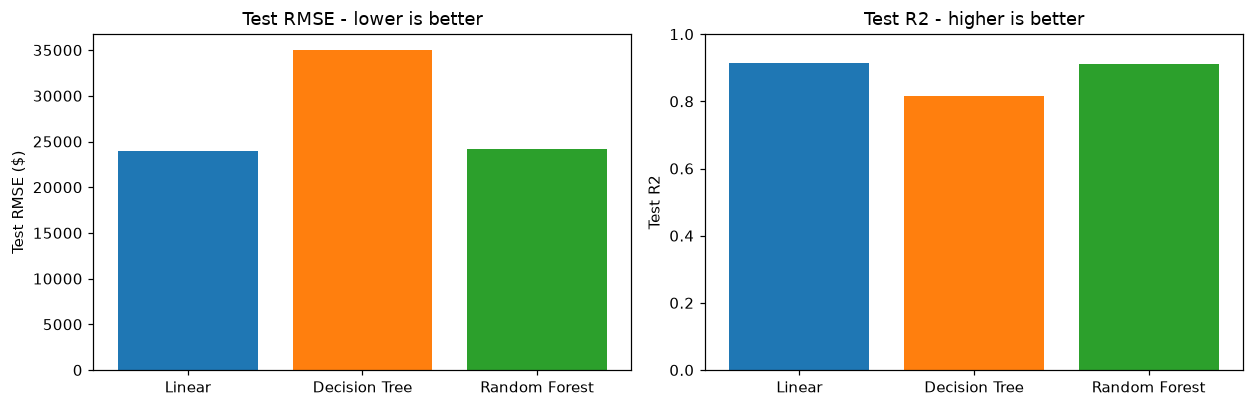

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
names = list(results_df.index)
short = [n.replace(" Regression", "") for n in names]

ax[0].bar(short, results_df["Test RMSE"], color=["tab:blue", "tab:orange", "tab:green"])
ax[0].set_ylabel("Test RMSE ($)"); ax[0].set_title("Test RMSE - lower is better")

ax[1].bar(short, results_df["Test R2"], color=["tab:blue", "tab:orange", "tab:green"])
ax[1].set_ylabel("Test R2"); ax[1].set_ylim(0, 1)
ax[1].set_title("Test R2 - higher is better")

plt.tight_layout(); plt.show()

### How to read these two numbers

**RMSE** is in dollars, the same unit as `SalePrice`, and lower is better. It is an *aggregate*
measure: an RMSE of \$30,000 does **not** mean every prediction is within \$30,000. Because
errors are squared before averaging, a few large misses raise it disproportionately.

**R²** compares the model against the simplest possible baseline - always predicting the mean
sale price. R² = 1 is perfect, R² = 0 means no better than that baseline, and R² can go
negative. It is **not** a percentage accuracy, and the brief specifically says not to describe
it that way.

### Interpreting the table

The interpretation of these results (the Linear Regression / Random Forest tie, the Decision
Tree's overfitting, and how much to trust a single split) is in **REPORT.md, Q6**.


## 6.3 Looking at the predictions, not just the metrics

Two models can share an RMSE while failing in completely different ways.

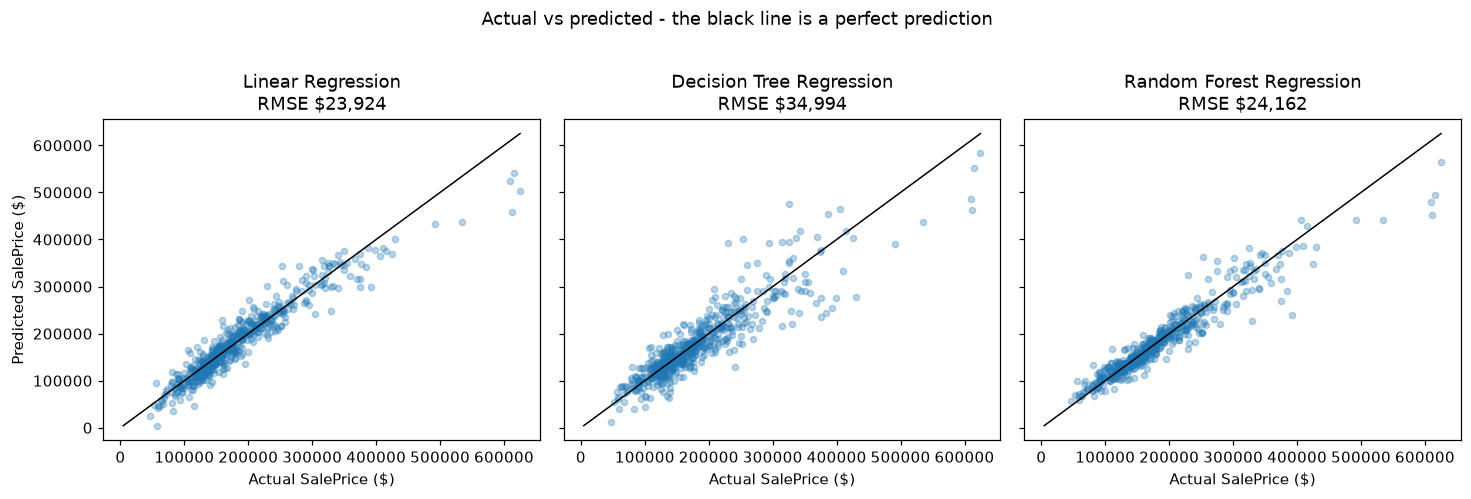

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.4), sharex=True, sharey=True)

lo = min(y_test.min(), min(p.min() for p in predictions.values()))
hi = max(y_test.max(), max(p.max() for p in predictions.values()))

for a, (name, y_pred) in zip(ax, predictions.items()):
    a.scatter(y_test, y_pred, alpha=0.3, s=16)
    a.plot([lo, hi], [lo, hi], color="black", lw=1)
    a.set_xlabel("Actual SalePrice ($)")
    a.set_title(f"{name}\nRMSE ${results_df.loc[name, 'Test RMSE']:,.0f}")
ax[0].set_ylabel("Predicted SalePrice ($)")

plt.suptitle("Actual vs predicted - the black line is a perfect prediction", y=1.02)
plt.tight_layout(); plt.show()

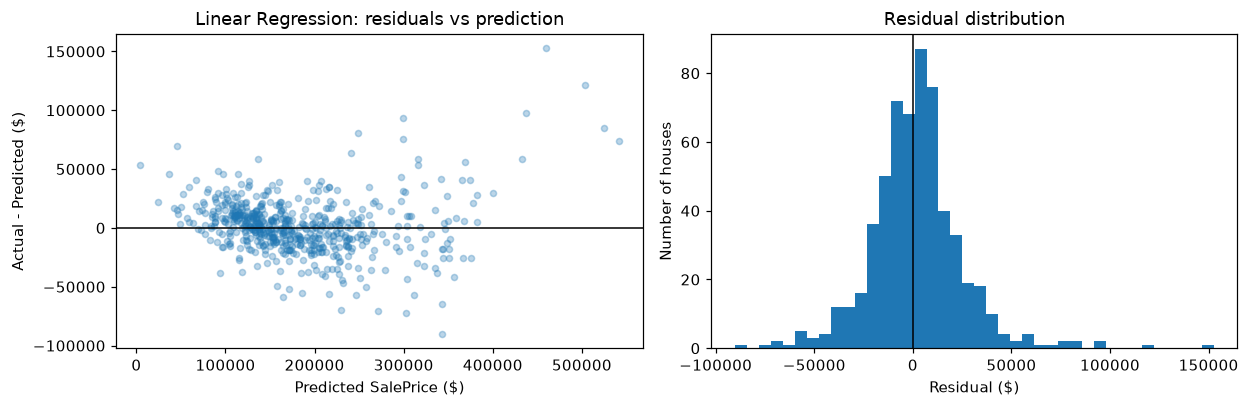

72% of test houses are predicted within $20,000 of the true price.
largest under-prediction: $152,509
largest over-prediction : $90,123


In [22]:
# Residuals of the best model: where, and by how much, is it wrong?
y_pred_best = predictions[best]
residuals = y_test - y_pred_best

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax[0].scatter(y_pred_best, residuals, alpha=0.3, s=16)
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xlabel("Predicted SalePrice ($)"); ax[0].set_ylabel("Actual - Predicted ($)")
ax[0].set_title(f"{best}: residuals vs prediction")

ax[1].hist(residuals, bins=40)
ax[1].axvline(0, color="black", lw=1)
ax[1].set_xlabel("Residual ($)"); ax[1].set_ylabel("Number of houses")
ax[1].set_title("Residual distribution")

plt.tight_layout(); plt.show()

within = (residuals.abs() < 20000).mean() * 100
print(f"{within:.0f}% of test houses are predicted within $20,000 of the true price.")
print(f"largest under-prediction: ${residuals.max():,.0f}")
print(f"largest over-prediction : ${-residuals.min():,.0f}")

## 6.4 Which features did the best model rely on?

Random forests expose `feature_importances_`, measuring how much each feature reduced error
across the ensemble. This is a **descriptive** check, not proof of causation - correlated
features share credit arbitrarily, so `Total SF` and `Gr Liv Area` will split the importance
of "size" between them.

It is still a useful cross-check on Step 1: if a feature the EDA called important turns up with
near-zero importance, one of the two analyses deserves a second look.

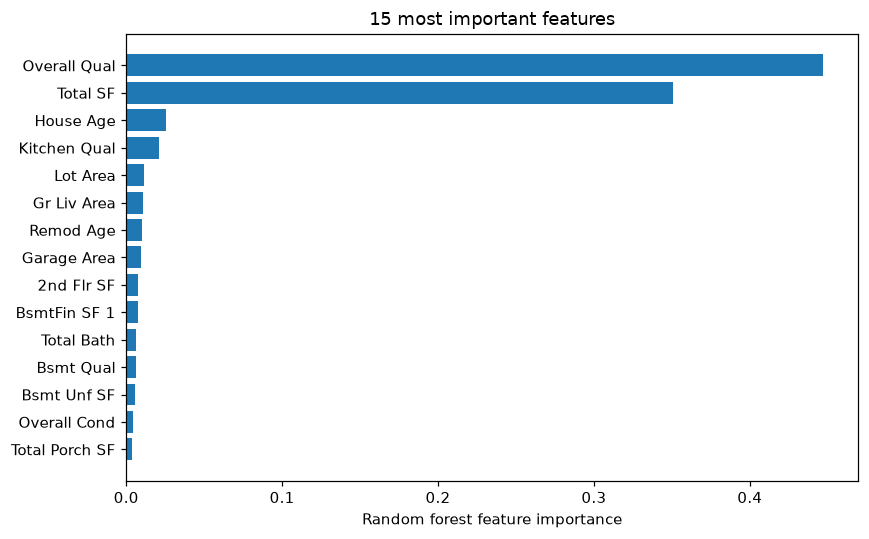

Engineered features and where they rank:
  Total SF         rank   2 of 259   importance 0.3509
  Total Bath       rank  11 of 259   importance 0.0066
  House Age        rank   3 of 259   importance 0.0253
  Remod Age        rank   7 of 259   importance 0.0102
  Total Porch SF   rank  15 of 259   importance 0.0038


In [23]:
rf = pipelines["Random Forest Regression"]
names_out = rf.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(
    rf.named_steps["regressor"].feature_importances_, index=names_out
).sort_values(ascending=False)

top = importances.head(15)[::-1]

plt.figure(figsize=(8, 5))
plt.barh([n.split("__", 1)[1] for n in top.index], top.values)
plt.xlabel("Random forest feature importance")
plt.title("15 most important features")
plt.tight_layout(); plt.show()

print("Engineered features and where they rank:")
for f in ["Total SF", "Total Bath", "House Age", "Remod Age", "Total Porch SF"]:
    key = f"num__{f}"
    if key in importances.index:
        print(f"  {f:16s} rank {importances.index.get_loc(key) + 1:3d} of {len(importances)}"
              f"   importance {importances[key]:.4f}")

## 6.5 Q7 - what would we change, without changing model?

Step 1.3 found `SalePrice` is right-skewed (skew 1.74), and that `log(SalePrice)` is almost
symmetric (skew -0.01). Linear regression minimises *squared* error on the raw scale, so the
handful of very expensive houses dominates the fit.

Training on `log(SalePrice)` and transforming the predictions back to dollars changes the
loss the model optimises without changing the algorithm - exactly what Q7 asks for. RMSE is
still computed in dollars, so the comparison below is like-for-like.

`TransformedTargetRegressor` handles the round trip, which keeps the transform inside the
pipeline where it belongs.

In [24]:
from sklearn.compose import TransformedTargetRegressor

log_results = []
for name, model in models.items():
    logged = Pipeline([
        ("preprocess", preprocess),
        ("regressor", TransformedTargetRegressor(
            regressor=model, func=np.log, inverse_func=np.exp,
        )),
    ])
    logged.fit(X_train, y_train)
    y_pred = logged.predict(X_test)      # already back-transformed to dollars

    log_results.append({
        "Model": name,
        "RMSE (raw target)": results_df.loc[name, "Test RMSE"],
        "RMSE (log target)": mean_squared_error(y_test, y_pred) ** 0.5,
        "R2 (raw target)":   results_df.loc[name, "Test R2"],
        "R2 (log target)":   r2_score(y_test, y_pred),
    })

log_df = pd.DataFrame(log_results).set_index("Model")
log_df["Change in RMSE"] = (log_df["RMSE (log target)"] - log_df["RMSE (raw target)"])

out = log_df.copy()
for c in ["RMSE (raw target)", "RMSE (log target)", "Change in RMSE"]:
    out[c] = out[c].map(lambda v: f"${v:,.0f}")
for c in ["R2 (raw target)", "R2 (log target)"]:
    out[c] = out[c].map(lambda v: f"{v:.3f}")
out

,RMSE (raw target),RMSE (log target),R2 (raw target),R2 (log target),Change in RMSE
Model,,,,,
Linear Regression,"$23,924","$20,335",0.914,0.938,"$-3,589"
Decision Tree Regression,"$34,994","$34,507",0.815,0.820,$-487
Random Forest Regression,"$24,162","$24,615",0.912,0.908,$453


**This is an experiment, not a change to the submitted result.** The Step 6.2 table remains the
official answer to Q6; this cell exists to give Q7 a number rather than a guess.

## 6.6 Other Q7 candidates

Other preprocessing and feature ideas we did not implement are listed in **REPORT.md, Q7**.



---

# Appendix A - Does stratifying the split actually help?

Section 2.2 claims that stratifying on `Overall Qual` balances the test set perfectly but does
not make the test score more stable. This is the experiment behind that claim.

**Method.** For each of 200 random seeds, split the data both ways, apply the *identical*
preprocessing and fit the *identical* model, then record the test RMSE. The only thing that
differs between the two arms is how `train_test_split` chooses rows. Linear Regression is used
because it is fast and because it was the best performer in Step 6.

`clone(preprocess)` gives a fresh, unfitted copy of the Step 3 preprocessor each time, so no
information leaks between runs.

This cell takes about a minute to run.


In [25]:

from sklearn.base import clone
from scipy import stats

N_SEEDS = 200
BINS, LABELS = [0, 4, 5, 6, 7, 8, 10], ["1-4", "5", "6", "7", "8", "9-10"]
overall_pct = qual_band.value_counts(normalize=True).sort_index() * 100


def evaluate_split(seed, stratify):
    """Run the full Step 2-6 workflow once and return (test RMSE, worst band drift)."""
    tr, te = train_test_split(
        df, test_size=0.20, random_state=seed,
        stratify=qual_band if stratify else None,
    )
    # same training-only outlier rule as Step 4.3
    tr = tr.loc[~((tr["Gr Liv Area"] > 4000) & (tr["Sale Condition"] == "Partial"))]

    Xtr = add_features(tr).drop(columns=DROP_COLS + [TARGET])
    Xte = add_features(te).drop(columns=DROP_COLS + [TARGET])

    pipe = Pipeline([("preprocess", clone(preprocess)), ("regressor", LinearRegression())])
    pipe.fit(Xtr, tr[TARGET])
    rmse = mean_squared_error(te[TARGET], pipe.predict(Xte)) ** 0.5

    te_pct = pd.cut(te["Overall Qual"], bins=BINS, labels=LABELS) \
               .value_counts(normalize=True).sort_index() * 100
    return rmse, (te_pct - overall_pct).abs().max()


arms = {}
for stratify in (False, True):
    runs = [evaluate_split(s, stratify) for s in range(N_SEEDS)]
    arms["stratified" if stratify else "random"] = (
        np.array([r[0] for r in runs]), np.array([r[1] for r in runs]))

print(f"{N_SEEDS} seeds per arm, identical pipeline, only the split differs\n")
print(f"{'':11s} {'mean':>9} {'median':>9} {'sd':>8} {'p10':>9} {'p90':>9}  {'worst drift':>11}")
for name, (rmse, drift) in arms.items():
    print(f"{name:11s} ${rmse.mean():>8,.0f} ${np.median(rmse):>8,.0f} ${rmse.std(ddof=1):>7,.0f} "
          f"${np.percentile(rmse, 10):>8,.0f} ${np.percentile(rmse, 90):>8,.0f}  {drift.max():>9.2f} pp")

rnd, strat = arms["random"][0], arms["stratified"][0]
F = strat.var(ddof=1) / rnd.var(ddof=1)
p_var = 2 * min(stats.f.cdf(F, N_SEEDS - 1, N_SEEDS - 1), 1 - stats.f.cdf(F, N_SEEDS - 1, N_SEEDS - 1))
_, p_mean = stats.ttest_ind(strat, rnd, equal_var=False)

print(f"\nvariance ratio (stratified / random) : {F:.3f}   (F-test p = {p_var:.2f})")
print(f"difference in means                  : ${strat.mean() - rnd.mean():+,.0f}   (Welch p = {p_mean:.2f})")
print("\n-> balancing works, but it does not make the score more stable.")

ours = results_df.loc["Linear Regression", "Test RMSE"]
print(f"\nOur reported result (stratified, seed {RANDOM_STATE}): ${ours:,.0f}")
print(f"  percentile among the {N_SEEDS} stratified seeds: {(strat < ours).mean() * 100:.0f}th")


200 seeds per arm, identical pipeline, only the split differs

                 mean    median       sd       p10       p90  worst drift
random      $  30,063 $  28,994 $  6,711 $  23,039 $  39,073       5.29 pp
stratified  $  30,361 $  28,892 $  6,730 $  23,230 $  39,282       0.07 pp

variance ratio (stratified / random) : 1.005   (F-test p = 0.97)
difference in means                  : $+299   (Welch p = 0.66)

-> balancing works, but it does not make the score more stable.

Our reported result (stratified, seed 42): $23,924
  percentile among the 200 stratified seeds: 17th


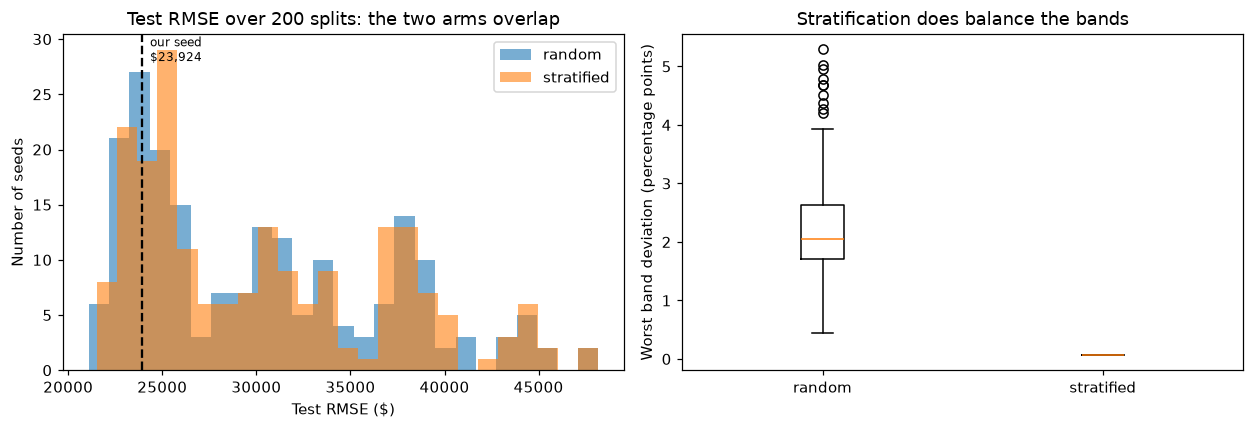

In [26]:

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))

ax[0].hist(rnd, bins=25, alpha=0.6, label="random")
ax[0].hist(strat, bins=25, alpha=0.6, label="stratified")
ax[0].axvline(ours, color="black", lw=1.5, ls="--")
ax[0].text(ours, ax[0].get_ylim()[1] * 0.92, f"  our seed\n  ${ours:,.0f}", fontsize=8)
ax[0].set_xlabel("Test RMSE ($)"); ax[0].set_ylabel("Number of seeds")
ax[0].set_title("Test RMSE over 200 splits: the two arms overlap")
ax[0].legend()

ax[1].boxplot([arms["random"][1], arms["stratified"][1]], tick_labels=["random", "stratified"])
ax[1].set_ylabel("Worst band deviation (percentage points)")
ax[1].set_title("Stratification does balance the bands")

plt.tight_layout(); plt.show()



**Reading the left panel.** The two histograms sit on top of each other. Whatever stratification
is doing, it is not narrowing the distribution of the test score. The dashed line marks the
seed we report, well inside the favourable tail.

**Reading the right panel.** Stratification is not failing at its job. Band drift collapses to
near zero. The balance is real; it simply does not translate into a more stable RMSE, because
the score is dominated by which individual high-price houses happen to fall in the test set.

**What we take from this.** Two things:

1. The choice between a random and a stratified split does not matter for this dataset. We keep
   stratification because a representative test set is worth having on its own terms, not
   because it improves the numbers.
2. Any single-split result carries roughly \$6,700 of seed noise, so differences between models
   smaller than that cannot be resolved by one split. This is the quantitative basis for
   calling Linear Regression and Random Forest a tie in 6.2.
